**Header**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/churn_project/'
PROC    = BASE + 'data/processed/'
RESULTS = BASE + 'results/'

print("✓ Ready")

Mounted at /content/drive
✓ Ready


**Load preprocessed data**

In [3]:
# Load the saved  data
with open(PROC + 'final_data.pkl', 'rb') as f:
    smoted = pickle.load(f)

datasets = ['Insurance', 'ISP', 'Telecom']

for name in datasets:
    X_tr = smoted[name]['X_train']
    X_te = smoted[name]['X_test']
    print(f"{name:12} → train: {X_tr.shape}  test: {X_te.shape}")

print("\n✓ Data loaded successfully")

Insurance    → train: (47905, 16)  test: (11977, 16)
ISP          → train: (64080, 9)  test: (14455, 9)
Telecom      → train: (4556, 19)  test: (667, 19)

✓ Data loaded successfully


**Train XGBoost on all 3 datasets:**

In [4]:
from xgboost import XGBClassifier

xgb_models = {}

for name in datasets:
    X_train = smoted[name]['X_train']
    y_train = smoted[name]['y_train']

    print(f"\nTraining XGBoost on {name}...")

    model = XGBClassifier(
        n_estimators      = 100,
        max_depth         = 6,
        learning_rate     = 0.1,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        use_label_encoder = False,
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1
    )

    model.fit(
        X_train, y_train,
        eval_set              = [(smoted[name]['X_test'],
                                  smoted[name]['y_test'])],
        verbose               = False
    )

    xgb_models[name] = model
    print(f"  ✓ {name} XGBoost trained")

print("\n✓ All 3 XGBoost models trained")


Training XGBoost on Insurance...
  ✓ Insurance XGBoost trained

Training XGBoost on ISP...
  ✓ ISP XGBoost trained

Training XGBoost on Telecom...
  ✓ Telecom XGBoost trained

✓ All 3 XGBoost models trained


**Evaluate all 3 models:**

In [5]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, cohen_kappa_score,
                              confusion_matrix)

def evaluate_model(name, model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]

    acc         = accuracy_score(y_test, y_pred)
    prec        = precision_score(y_test, y_pred, zero_division=0)
    rec         = recall_score(y_test, y_pred, zero_division=0)
    f1          = f1_score(y_test, y_pred, zero_division=0)
    auc         = roc_auc_score(y_test, y_prob)
    kappa       = cohen_kappa_score(y_test, y_pred)

    # True/False churn from confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity    = tn / (tn + fp)

    return {
        'Dataset'     : name,
        'Model'       : 'XGBoost',
        'Accuracy'    : round(acc   * 100, 2),
        'Precision'   : round(prec  * 100, 2),
        'Recall'      : round(rec   * 100, 2),
        'F1 Score'    : round(f1    * 100, 2),
        'ROC AUC'     : round(auc   * 100, 2),
        'Kappa'       : round(kappa,        4),
        'Specificity' : round(specificity * 100, 2),
        'True Churn'  : int(tp),
        'False Churn' : int(fp)
    }

results = []
for name in datasets:
    res = evaluate_model(
        name,
        xgb_models[name],
        smoted[name]['X_test'],
        smoted[name]['y_test']
    )
    results.append(res)
    print(f"\n{name} XGBoost Results:")
    print(f"  Accuracy  : {res['Accuracy']}%")
    print(f"  Precision : {res['Precision']}%")
    print(f"  Recall    : {res['Recall']}%")
    print(f"  F1 Score  : {res['F1 Score']}%")
    print(f"  ROC AUC   : {res['ROC AUC']}%")
    print(f"  Kappa     : {res['Kappa']}")

results_df = pd.DataFrame(results)
display(results_df)


Insurance XGBoost Results:
  Accuracy  : 89.94%
  Precision : 87.45%
  Recall    : 93.25%
  F1 Score  : 90.26%
  ROC AUC   : 95.57%
  Kappa     : 0.7988

ISP XGBoost Results:
  Accuracy  : 94.08%
  Precision : 95.91%
  Recall    : 93.3%
  F1 Score  : 94.58%
  ROC AUC   : 98.08%
  Kappa     : 0.8806

Telecom XGBoost Results:
  Accuracy  : 95.05%
  Precision : 82.98%
  Recall    : 82.11%
  F1 Score  : 82.54%
  ROC AUC   : 92.28%
  Kappa     : 0.7966


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Kappa,Specificity,True Churn,False Churn
0,Insurance,XGBoost,89.94,87.45,93.25,90.26,95.57,0.7988,86.63,5584,801
1,ISP,XGBoost,94.08,95.91,93.30,94.58,98.08,0.8806,95.05,7473,319
2,Telecom,XGBoost,95.05,82.98,82.11,82.54,92.28,0.7966,97.20,78,16


**Plot confusion matrices for all 3:**

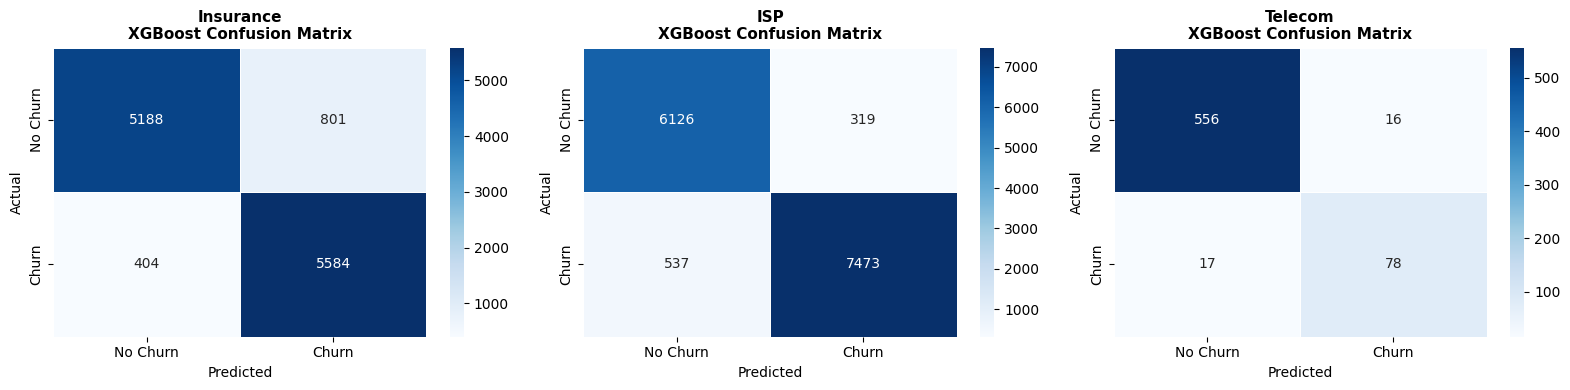

✓ Saved confusion matrices


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name in zip(axes, datasets):
    model  = xgb_models[name]
    X_test = smoted[name]['X_test']
    y_test = smoted[name]['y_test']
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, ax=ax,
        annot=True, fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        linewidths=0.5
    )
    ax.set_title(f'{name}\nXGBoost Confusion Matrix',
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(RESULTS + 'xgboost_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved confusion matrices")

**Plot ROC curves for all 3:**

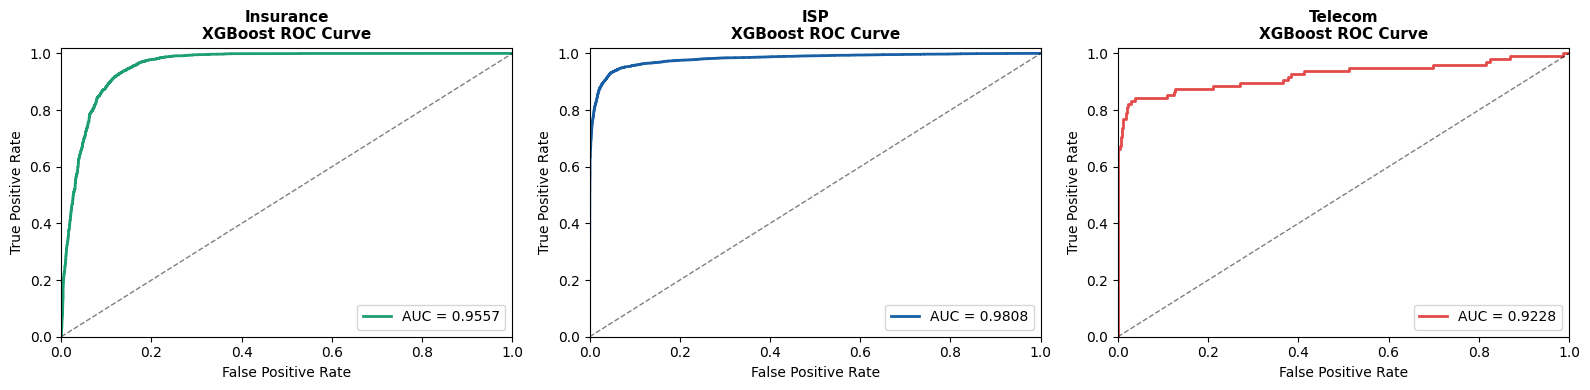

✓ Saved ROC curves


In [7]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors    = ['#1D9E75', '#185FA5', '#E24B4A']

for ax, name, color in zip(axes, datasets, colors):
    model  = xgb_models[name]
    X_test = smoted[name]['X_test']
    y_test = smoted[name]['y_test']
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'AUC = {auc:.4f}')
    ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5)
    ax.set_title(f'{name}\nXGBoost ROC Curve',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(RESULTS + 'xgboost_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved ROC curves")

**Feature importance plots:**

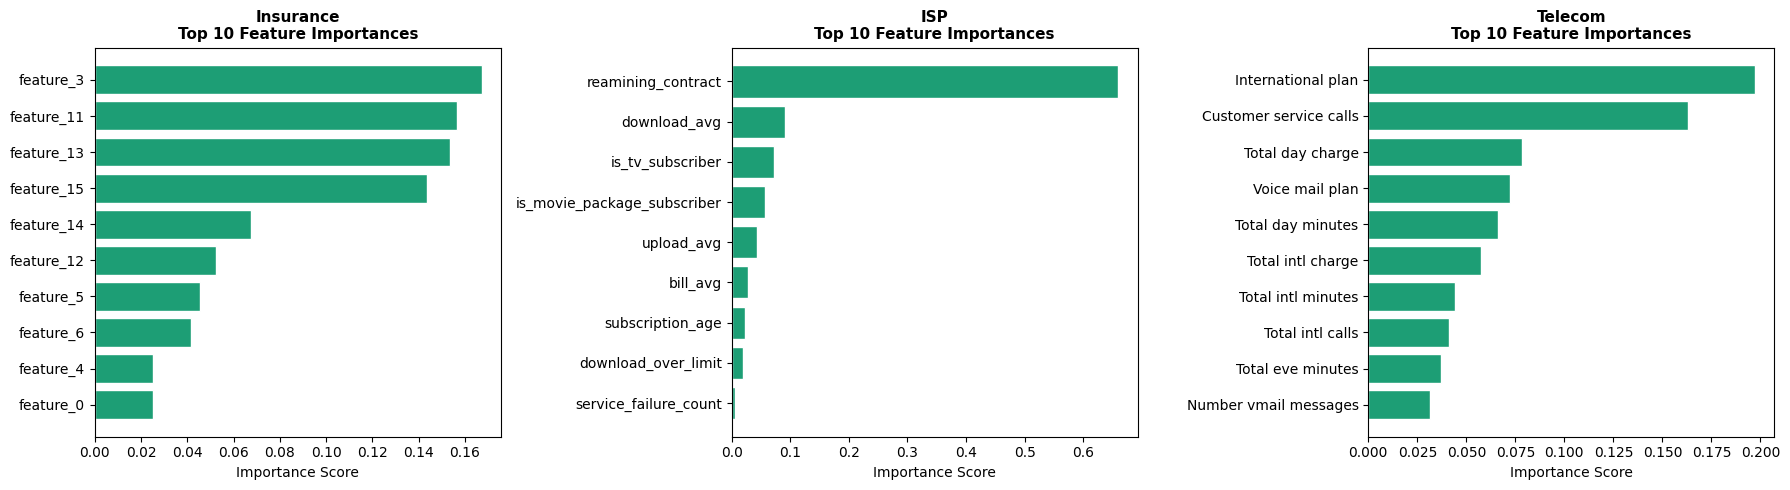

✓ Saved feature importance plots


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, datasets):
    model        = xgb_models[name]
    X_train      = smoted[name]['X_train']
    feature_names = X_train.columns.tolist()

    importances  = model.feature_importances_
    indices      = np.argsort(importances)[::-1][:10]  # top 10

    top_features = [feature_names[i] for i in indices]
    top_scores   = importances[indices]

    bars = ax.barh(top_features[::-1], top_scores[::-1],
                   color='#1D9E75', edgecolor='white')
    ax.set_title(f'{name}\nTop 10 Feature Importances',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(RESULTS + 'xgboost_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved feature importance plots")

**Save XGBoost results and models:**

In [9]:
# Save results to CSV
results_df.to_csv(RESULTS + 'xgboost_results.csv', index=False)
print("✓ Results saved → results/xgboost_results.csv")

# Save trained models
with open(PROC + 'xgb_models.pkl', 'wb') as f:
    pickle.dump(xgb_models, f)
print("✓ Models saved  → data/processed/xgb_models.pkl")

print("\n" + "="*50)
print("  XGBoost notebook complete")
print("="*50)
print("\nYour results vs paper targets:")
print(f"{'Dataset':<12} {'Your Accuracy':>15} {'Paper Target':>14}")
print("-"*42)
targets = {'Insurance': '~93%', 'ISP': '~96%', 'Telecom': '~98%'}
for _, row in results_df.iterrows():
    print(f"{row['Dataset']:<12} {row['Accuracy']:>14}%"
          f" {targets[row['Dataset']]:>14}")

print("\n✓ Next step: run 04_cnn_models notebook")

✓ Results saved → results/xgboost_results.csv
✓ Models saved  → data/processed/xgb_models.pkl

  XGBoost notebook complete

Your results vs paper targets:
Dataset        Your Accuracy   Paper Target
------------------------------------------
Insurance             89.94%           ~93%
ISP                   94.08%           ~96%
Telecom               95.05%           ~98%

✓ Next step: run 04_cnn_models notebook
